In [1]:
import pandas as pd
# Powershell pip install requests        
# %pip install requests
import requests

# Importar dataset Titanic desde el enlace
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
response=requests.get(url)


print("Respuesta:",response.status_code)

try:
    print("Link de datos valido")
    df_titanic = pd.read_csv(url)
except:
    print("no hay buen acceso o caduco el link")

# Mostrar primeras filas
print(df_titanic.head())
print(df_titanic.tail())

Respuesta: 200
Link de datos valido
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0           

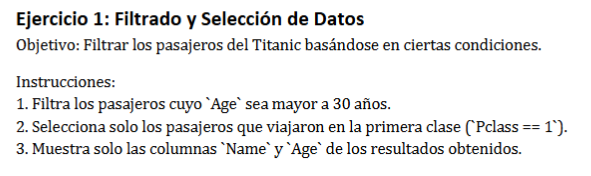

In [ ]:
df_titanic.info()
df_ejercicio1=df_titanic.copy()
print(f"\nOriginal tamanio {len(df_titanic)}\n")
# true y false si cumple la condicion
# df_ejercicio1["Age"] = df_ejercicio1["Age"] > 30
# filtrar
df_mayores30 = df_ejercicio1.loc[df_ejercicio1["Age"] > 30]
print(f"\nFiltrado tamanio mayores de 30: {len(df_mayores30)}\n")

df_primeraclase = df_ejercicio1.loc[df_ejercicio1["Pclass"] == 1]
print(f"\nFiltrado tamanio primera clase: {len(df_primeraclase)}\n")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Original tamanio 891


Filtrado tamanio mayores de 30: 305


Filtrado tamanio primera clase: 216


Ambos filtros: 125

     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6         

In [12]:
##juntar filtros
df_resultado_1 = df_ejercicio1.loc[(df_ejercicio1["Age"] > 30) & (df_ejercicio1["Pclass"] == 1)]
print(f"\nAmbos filtros: {len(df_resultado_1)}\n")
print(df_resultado_1[["Name","Age"]])


Ambos filtros: 125

                                                  Name   Age
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
6                              McCarthy, Mr. Timothy J  54.0
11                            Bonnell, Miss. Elizabeth  58.0
30                            Uruchurtu, Don. Manuel E  40.0
..                                                 ...   ...
862  Swift, Mrs. Frederick Joel (Margaret Welles Ba...  48.0
867               Roebling, Mr. Washington Augustus II  31.0
871   Beckwith, Mrs. Richard Leonard (Sallie Monypeny)  47.0
872                           Carlsson, Mr. Frans Olof  33.0
879      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  56.0

[125 rows x 2 columns]


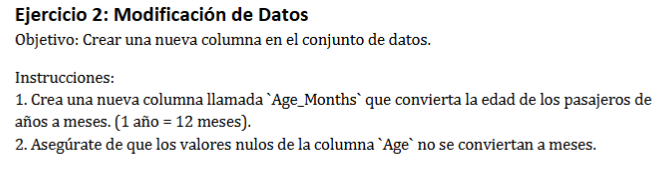

In [15]:
df_ejercicio2=df_titanic.copy()
df_ejercicio2["age_months"]=df_ejercicio2["Age"].dropna()
df_ejercicio2["age_months"]=df_ejercicio2["Age"]*12
print(f"\nEdad en meses tamanio : {len(df_ejercicio2)}\n")
print(df_ejercicio2)


Edad en meses tamanio : 891

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

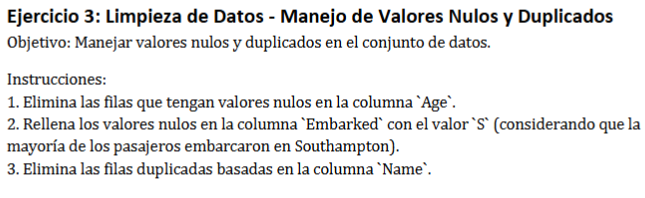

In [38]:
df_limpio=df_titanic.copy()
print(f" sin limpiar {len(df_limpio)}\n")
df_limpio = df_limpio.dropna(subset=["Age"])
print(f" sin limpiar {len(df_limpio)}\n")

 sin limpiar 891

 sin limpiar 714



In [39]:
# 2 reemplazar nulos
print(df_limpio["Embarked"].isna().sum())
df_limpio["Embarked"] = df_limpio["Embarked"].fillna("S")
print((df_limpio["Embarked"] == "S").sum())

2
556


In [ ]:
# 3 eliminar duplicados
print(f" Con duplicados {len(df_limpio)}\n")
df_limpio = df_limpio.drop_duplicates(subset=["Name"])
print(f" Sin duplicados {len(df_limpio)}\n")

 Con duplicados 714

 Sin duplicados 714



##### Ejercicio 4
agrupar y operaciones agregadas

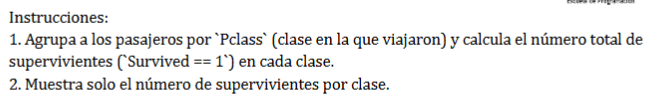

In [ ]:
## selecionar la columna de una agrupacion 
#cuantos dobrebibieron de cada clase
print(df_limpio.groupby("Pclass")["Survived"].sum())

Pclass
1    122
2     83
3     85
Name: Survived, dtype: int64


In [ ]:
## funcion personalizada de agregacion 
print(df_limpio.groupby("Pclass")["Age"].agg(["mean", "min", "max", "count"]))


             mean   min   max  count
Pclass                              
1       38.233441  0.92  80.0    186
2       29.877630  0.67  70.0    173
3       25.140620  0.42  74.0    355


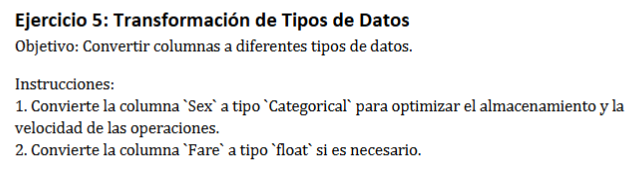

In [44]:
print(df_limpio.dtypes)
# Convertir columna 'Sex' a tipo categorico
df_limpio["Sex"] = df_limpio["Sex"].astype("category")

# Asegurar que 'Fare' esté en float64
df_limpio["Fare"] = df_limpio["Fare"].astype("float64")

print(df_limpio.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
dtype: object


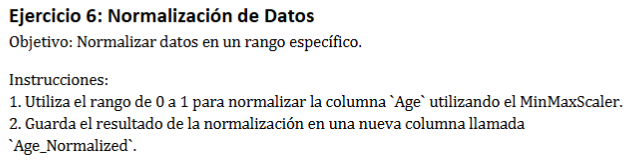

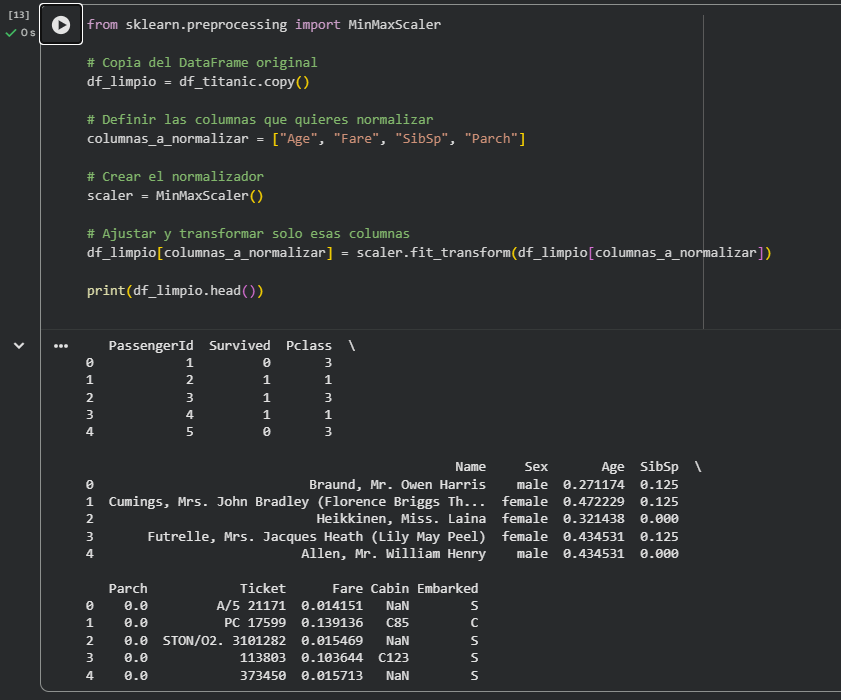

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Copia del DataFrame original
# df_limpio = df_titanic.copy()

# # Definir las columnas que quieres normalizar
# columnas_a_normalizar = ["Age", "Fare", "SibSp", "Parch"]

# # Crear el normalizador
# scaler = MinMaxScaler()

# # Ajustar y transformar solo esas columnas
# df_limpio[columnas_a_normalizar] = scaler.fit_transform(df_limpio[columnas_a_normalizar])

# print(df_limpio.head())
